# **Laboratorio 6 - Visión por Computadora**

- Paula Barillas - 22764
- Gerardo Pineda - 22880
- Monica Salvatierra - 22249

Link del repositorio: https://github.com/paulabaal12/LAB6-VCP

---

## **Task 1**
---

**Como Ingeniero Principal (Lead AI Engineer) del proyecto AgriTech, usted debe justificar las decisiones arquitectónicas ante su equipo y sus clientes. Responda a los siguientes escenarios en su reporte (máximo 1 página por respuesta), combinando la teoría matemática con el pragmatismo laboral.**




**1. Un desarrollador junior de su equipo sugiere: "Para detectar con mayor precisión las texturas de las hojas enfermas, deberíamos construir una red secuencial clásica (tipo VGG) pero de 150 capas. Más profundo siempre es mejor". Como líder técnico, explíquele argumentativamente por qué esta red fracasará estrepitosamente en el entrenamiento (mencionando el fenómeno de degradación y el desvanecimiento del gradiente). Luego, justifique cómo la adición estructural de las conexiones residuales (𝐹(𝑥) + 𝑥) de ResNet rescata el proyecto, haciendo viable entrenar redes ultra-profundas sin colapsar.**

- Aunque la intuición de que “más profundo es mejor” parece razonable, en la práctica una red secuencial tipo VGG con 150 capas probablemente fracasaría durante el entrenamiento. El problema principal es conocido como vanishing gradient o desvanecimiento del gradiente. Durante el entrenamiento con backpropagation, el gradiente que actualiza los pesos se propaga desde la salida hacia las primeras capas. A medida que atraviesa muchas capas, ese gradiente tiende a hacerse cada vez más pequeño, hasta el punto en que las primeras capas prácticamente dejan de aprender. En redes extremadamente profundas esto provoca que el modelo se estanque y no logre optimizarse correctamente.

    Relacionado con esto, también podría suceder la degradación. Cuando se agregan muchas capas adicionales a una red profunda, el error de entrenamiento puede incluso aumentar en lugar de disminuir. En teoría, una red más profunda debería poder al menos replicar el comportamiento de una red más pequeña aprendiendo una función identidad en las capas adicionales. Sin embargo, en arquitecturas secuenciales esto es difícil de lograr durante la optimización, por lo que el entrenamiento se vuelve inestable o ineficiente.

    Aquí es donde entra la contribución clave de ResNet. Las redes residuales introducen conexiones de salto que permiten que la salida de un bloque se exprese como 𝐹(𝑥)+𝑥. En lugar de aprender directamente una transformación compleja, la red aprende una función residual 𝐹(𝑥), es decir, la diferencia entre la entrada y la salida deseada. Desde el punto de vista del entrenamiento, esto crea rutas más cortas por las que el gradiente puede propagarse hacia atrás sin degradarse tanto. Si el bloque residual no necesita modificar significativamente la información, puede aprender fácilmente una función cercana a cero y dejar pasar la señal original.

    En términos prácticos, estas conexiones actúan como autopistas para la información y para el gradiente. Gracias a ello se vuelve viable entrenar redes de más de cien capas sin que el proceso de optimización colapse. Por esta razón, en un proyecto real como AgriTech, optar por una arquitectura residual profunda sería una decisión mucho más sólida que intentar escalar una arquitectura VGG tradicional a 150 capas.


**2. Las enfermedades en las hojas de mango son visualmente heterogéneas: La Antracnosis se
presenta como puntos negros diminutos, mientras que el Moho Polvoriento cubre áreas enormes de la hoja. Analice cómo la topología en paralelo del módulo Inception (usando filtros 3x3 y 5x5 simultáneamente) es ideal para este problema biológico en particular. Además, desde una perspectiva de costos de infraestructura (uso de GPUs en AWS o Google Cloud), explique cómo la inserción estratégica de convoluciones de 1x1 evita la explosión de la dimensionalidad y salva el presupuesto mensual de la startup.**

- En el caso de las hojas de mango, el reto principal es que las enfermedades no aparecen siempre con la misma escala visual. La antracnosis se manifiesta como pequeños puntos oscuros dispersos en la hoja, mientras que el moho polvoriento suele cubrir regiones amplias con una textura difusa. Esto significa que el modelo debe ser capaz de detectar patrones tanto muy pequeños como relativamente grandes dentro de la misma imagen.

    La arquitectura Inception aborda este problema mediante una topología en paralelo. En lugar de aplicar un único tamaño de filtro en cada capa, el módulo Inception procesa la misma entrada utilizando múltiples convoluciones simultáneamente, como filtros 3x3 y 5x5. Cada uno de estos filtros captura información a una escala diferente. Los filtros más pequeños son buenos para detectar detalles finos y bordes locales, mientras que los filtros más grandes capturan patrones más extendidos en la imagen. Al combinar estas salidas en un mismo bloque, la red aprende representaciones multiescala, lo cual es particularmente adecuado para fenómenos biológicos donde los síntomas visuales varían mucho en tamaño.

    Sin embargo, este diseño también introduce un problema práctico importante. Ejecutar múltiples convoluciones grandes en paralelo aumenta considerablemente el número de canales y el costo computacional. En un entorno de producción donde el entrenamiento se ejecuta en GPUs en servicios como AWS o Google Cloud, esto puede traducirse rápidamente en un aumento significativo del costo de infraestructura.

    La solución propuesta por Inception consiste en insertar convoluciones de 1x1 antes de las convoluciones más costosas. Estas convoluciones funcionan como capas de reducción de dimensionalidad. Matemáticamente actúan como combinaciones lineales de los canales de entrada, reduciendo el número de mapas de características antes de aplicar filtros más grandes. De esta forma se disminuye la cantidad de operaciones necesarias sin perder demasiada información relevante.

    Desde la perspectiva de una startup, esta decisión arquitectónica tiene un impacto directo en el presupuesto. Reducir la dimensionalidad antes de aplicar convoluciones pesadas permite entrenar modelos complejos sin que el consumo de memoria y cómputo se dispare. En otras palabras, las convoluciones 1x1 no solo mejoran la eficiencia del modelo, sino que también ayudan a mantener el costo operativo del proyecto dentro de límites razonables.

**3. El cliente final (el agricultor) usará la aplicación en un teléfono Android de gama baja en medio del campo, sin conexión a internet. Sabemos que MobileNet logra esta eficiencia gracias a la Depthwise Separable Convolution. Describa brevemente cómo esta convolución divide el trabajo (filtrado espacial vs. combinación de canales). Sin embargo, en ingeniería no hay soluciones mágicas, todo tiene un precio: ¿Qué capacidad matemática o expresividad de la red se está sacrificando al separar estos dos pasos en comparación con una convolución estándar? Analice críticamente por qué, como director del proyecto, usted acepta pagar ese "costo" en este escenario comercial.**

- Cuando el sistema debe ejecutarse en un teléfono Android de gama baja y sin conexión a internet, la eficiencia computacional se vuelve un requisito crítico. MobileNet logra esta eficiencia mediante el uso de depthwise separable convolutions. En lugar de realizar una convolución estándar que mezcla simultáneamente información espacial y entre canales, este tipo de convolución divide el proceso en dos pasos.

    Primero se aplica una convolución depthwise, en la que cada canal de la imagen se filtra de forma independiente utilizando un filtro espacial, por ejemplo de 3x3. Este paso captura patrones espaciales dentro de cada canal, como bordes o texturas. Luego se aplica una convolución pointwise de 1x1 que combina la información entre los distintos canales. Este segundo paso permite mezclar las características aprendidas en el espacio de canales.

    La ventaja principal es que el número de operaciones se reduce drásticamente en comparación con una convolución estándar. Esto disminuye tanto el uso de memoria como el tiempo de inferencia, lo cual es esencial cuando el modelo se ejecuta directamente en un dispositivo móvil con recursos limitados.

    Sin embargo, esta eficiencia no es gratis. Al separar el filtrado espacial y la combinación de canales, la red pierde parte de la flexibilidad matemática que tiene una convolución tradicional. En una convolución estándar, cada filtro puede aprender simultáneamente patrones espaciales y relaciones entre canales, lo que le da mayor capacidad expresiva. En cambio, en una depthwise separable convolution estas interacciones se restringen porque los dos procesos se realizan de manera independiente.

    Como director del proyecto, aceptar este costo es una decisiónbasada en el contexto del producto. Nuestro usuario final es un agricultor que necesita obtener una predicción rápida directamente desde su teléfono, posiblemente en medio del campo y sin conectividad. Un modelo ligeramente menos expresivo pero que pueda ejecutarse localmente en tiempo real tiene mucho más valor práctico que un modelo más complejo que requiera servidores o GPUs remotas. En este escenario, la ganancia en eficiencia y accesibilidad supera ampliamente la pequeña pérdida en capacidad del modelo.

## **Task 2**
---

In [1]:
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo utilizado: {device}")

Dispositivo utilizado: cpu


In [2]:
# Transformaciones para entrenamiento
train_transform = transforms.Compose([ transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
])

# Transformaciones para validacion y prueba
val_test_transform = transforms.Compose([
    transforms.Resize(256),transforms.CenterCrop(224),
    transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
])

# Transformaciones para InceptionV3 (requiere 299x299)
train_transform_inception = transforms.Compose([
    transforms.RandomResizedCrop(299, scale=(0.8, 1.0)),transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(), transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform_inception = transforms.Compose([
    transforms.Resize(320), transforms.CenterCrop(299),
    transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Transformaciones definidas")

Transformaciones definidas


#### **Entrenamiento (70%), Validacion (15%) y Prueba (15%)**

In [3]:
DATA_DIR = "data"
NUM_CLASSES = 8
BATCH_SIZE = 32

full_dataset = datasets.ImageFolder(root=DATA_DIR)
class_names = full_dataset.classes
targets = full_dataset.targets

print(f"Clases encontradas: {class_names}")
print(f"Total de imagenes: {len(full_dataset)}")
print(f"Distribucion por clase: {dict(Counter(targets))}")

# 70% train, 15% val, 15% test
indices = list(range(len(full_dataset)))
train_idx, temp_idx = train_test_split(indices, test_size=0.30, stratify=targets, random_state=42)
temp_targets = [targets[i] for i in temp_idx]
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, stratify=temp_targets, random_state=42)

print(f"\nTamaño del conjunto de entrenamiento: {len(train_idx)} ({len(train_idx)/len(full_dataset)*100:.1f}%)")
print(f"Tamaño del conjunto de validacion: {len(val_idx)} ({len(val_idx)/len(full_dataset)*100:.1f}%)")
print(f"Tamaño del conjunto de prueba: {len(test_idx)} ({len(test_idx)/len(full_dataset)*100:.1f}%)")

Clases encontradas: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Total de imagenes: 4000
Distribucion por clase: {0: 500, 1: 500, 2: 500, 3: 500, 4: 500, 5: 500, 6: 500, 7: 500}

Tamaño del conjunto de entrenamiento: 2800 (70.0%)
Tamaño del conjunto de validacion: 600 (15.0%)
Tamaño del conjunto de prueba: 600 (15.0%)


In [4]:
class TransformedSubset(torch.utils.data.Dataset):
    """aplica una transformacion especifica a un Subset."""
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

    def __len__(self):
        return len(self.subset)

# Dataset base sin transformaciones
base_dataset = datasets.ImageFolder(root=DATA_DIR)

train_subset = Subset(base_dataset, train_idx)
val_subset = Subset(base_dataset, val_idx)
test_subset = Subset(base_dataset, test_idx)

# DataLoaders para ResNet50 y MobileNetV2
train_loader_224 = DataLoader(TransformedSubset(train_subset, train_transform), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader_224 = DataLoader(TransformedSubset(val_subset, val_test_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader_224 = DataLoader(TransformedSubset(test_subset, val_test_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# DataLoaders para InceptionV3 (299x299)
train_loader_299 = DataLoader(TransformedSubset(train_subset, train_transform_inception), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader_299 = DataLoader(TransformedSubset(val_subset, val_test_transform_inception), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader_299 = DataLoader(TransformedSubset(test_subset, val_test_transform_inception),batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"DataLoaders")
print(f"Batches de entrenamiento (224): {len(train_loader_224)}")
print(f"Batches de validacion (224): {len(val_loader_224)}")
print(f"Batches de prueba (224): {len(test_loader_224)}")
print(f"Batches de entrenamiento (299): {len(train_loader_299)}")
print(f"Batches de validacion (299): {len(val_loader_299)}")
print(f"Batches de prueba (299): {len(test_loader_299)}")

DataLoaders
Batches de entrenamiento (224): 88
Batches de validacion (224): 19
Batches de prueba (224): 19
Batches de entrenamiento (299): 88
Batches de validacion (299): 19
Batches de prueba (299): 19


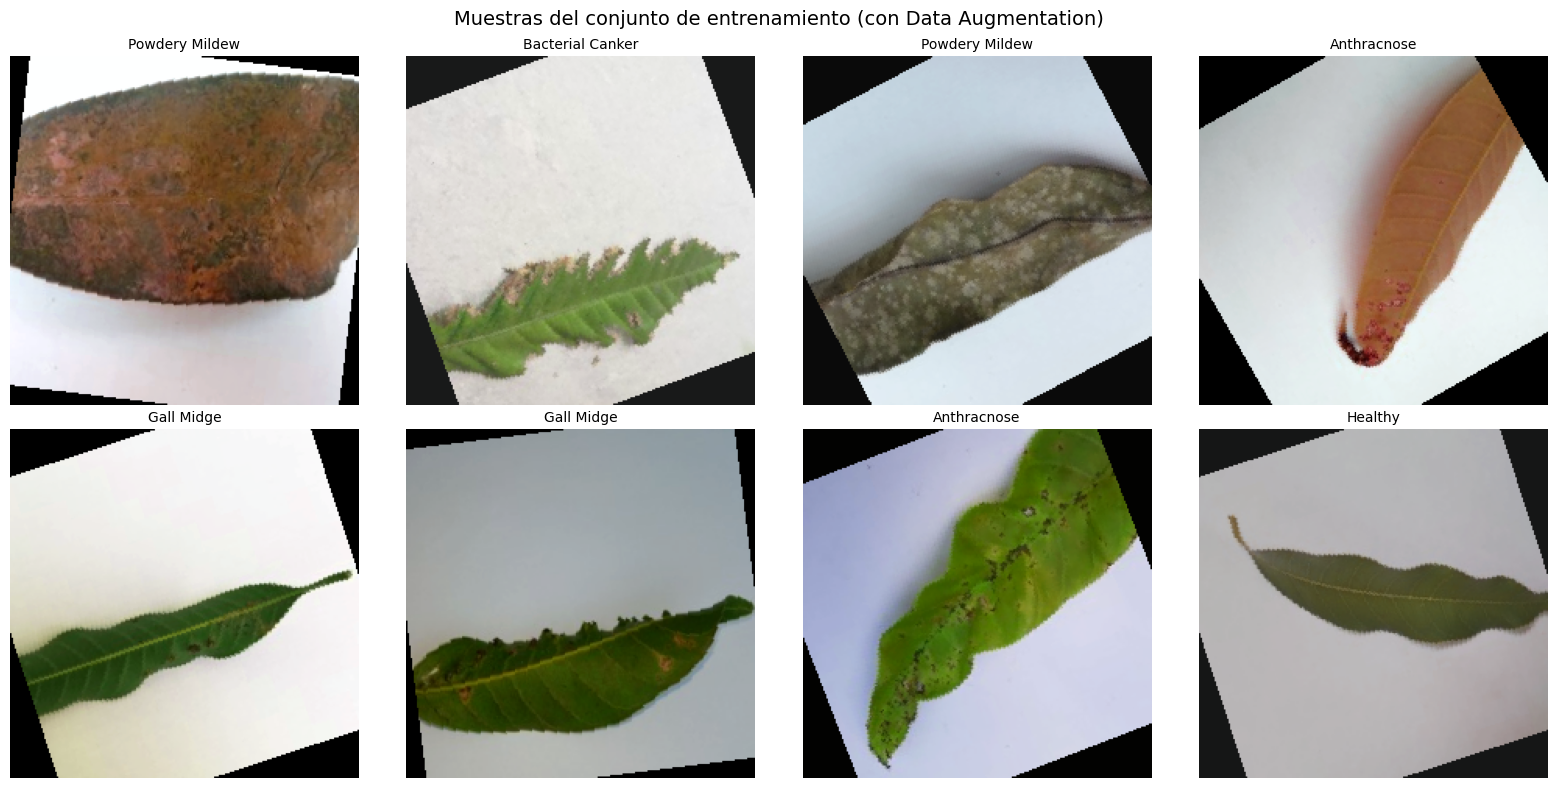

In [5]:
def imshow(inp, title=None):
    """imagen desnormalizada."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)

images, labels = next(iter(train_loader_224))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    ax.axis('off')
    inp = images[i].numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    ax.imshow(inp)
    ax.set_title(class_names[labels[i]], fontsize=10)

plt.suptitle("Muestras del conjunto de entrenamiento (con Data Augmentation)", fontsize=14)
plt.tight_layout()
plt.show()

#### **ResNet50**

In [6]:
def create_resnet50(num_classes=8):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    # Congela todas las capas base
    for param in model.parameters():
        param.requires_grad = False

    # Reemplazar el cabezal de clasificacion
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_features, num_classes)
    )

    return model

resnet50 = create_resnet50(NUM_CLASSES).to(device)

total_params = sum(p.numel() for p in resnet50.parameters())
trainable_params = sum(p.numel() for p in resnet50.parameters() if p.requires_grad)
print(f"Parametros totales: {total_params:,}")
print(f"Parametros entrenables: {trainable_params:,}")
print(f"Parametros congelados: {total_params - trainable_params:,}")

Parametros totales: 23,524,424
Parametros entrenables: 16,392
Parametros congelados: 23,508,032


#### **InceptionV3**

In [7]:
def create_inceptionv3(num_classes=8):
    model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)

    # Congela todas las capas base
    for param in model.parameters():
        param.requires_grad = False

    # Reemplazar el cabezal de clasificacion principal
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_features, num_classes)
    )

    num_features_aux = model.AuxLogits.fc.in_features
    model.AuxLogits.fc = nn.Linear(num_features_aux, num_classes)

    # gradientes en los nuevos cabezales
    for param in model.fc.parameters():
        param.requires_grad = True
    for param in model.AuxLogits.fc.parameters():
        param.requires_grad = True

    return model

inceptionv3 = create_inceptionv3(NUM_CLASSES).to(device)

total_params = sum(p.numel() for p in inceptionv3.parameters())
trainable_params = sum(p.numel() for p in inceptionv3.parameters() if p.requires_grad)
print(f"Parametros totales: {total_params:,}")
print(f"Parametros entrenables: {trainable_params:,}")
print(f"Parametros congelados: {total_params - trainable_params:,}")

Parametros totales: 24,365,808
Parametros entrenables: 22,544
Parametros congelados: 24,343,264


#### **MobileNetV2**

In [8]:
def create_mobilenetv2(num_classes=8):
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

    # Congelar todas las capas base
    for param in model.parameters():
        param.requires_grad = False

    # Reemplazar el clasificador
    num_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_features, num_classes)
    )

    return model

mobilenetv2 = create_mobilenetv2(NUM_CLASSES).to(device)

total_params = sum(p.numel() for p in mobilenetv2.parameters())
trainable_params = sum(p.numel() for p in mobilenetv2.parameters() if p.requires_grad)
print(f"Parametros totales: {total_params:,}")
print(f"Parametros entrenables: {trainable_params:,}")
print(f"Parametros congelados: {total_params - trainable_params:,}")

Parametros totales: 2,234,120
Parametros entrenables: 10,248
Parametros congelados: 2,223,872


#### **Entrenamiento de los modelos**


#### **Early Stopping**

In [9]:
def train_model(model, train_loader, val_loader, model_name, num_epochs=20, patience=5, is_inception=False):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

    best_val_loss = float('inf')
    best_model_weights = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            if is_inception:
                outputs, aux_outputs = model(inputs)
                loss1 = criterion(outputs, labels)
                loss2 = criterion(aux_outputs, labels)
                loss = loss1 + 0.4 * loss2
            else:
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / total
        epoch_train_acc = correct / total

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct / val_total

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)

        print(f"[{model_name}] Epoca {epoch+1}/{num_epochs} - "
              f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} - "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

        # Early Stopping
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"\nEarly Stopping activado en la epoca {epoch+1}. Restaurando mejores pesos.")
                break

    model.load_state_dict(best_model_weights)
    return model, history

#### **ResNet50**

In [10]:
print("Entrenamiento de ResNet50")
print("=" * 80)
resnet50, history_resnet = train_model(
    resnet50, train_loader_224, val_loader_224,
    model_name="ResNet50", num_epochs=20, patience=5, is_inception=False
)
print("\nEntrenamiento de ResNet50 finalizado.")

Entrenamiento de ResNet50
[ResNet50] Epoca 1/20 - Train Loss: 1.0238, Train Acc: 0.7275 - Val Loss: 0.4220, Val Acc: 0.8933
[ResNet50] Epoca 2/20 - Train Loss: 0.4095, Train Acc: 0.9075 - Val Loss: 0.2565, Val Acc: 0.9450
[ResNet50] Epoca 3/20 - Train Loss: 0.2931, Train Acc: 0.9300 - Val Loss: 0.2171, Val Acc: 0.9483
[ResNet50] Epoca 4/20 - Train Loss: 0.2645, Train Acc: 0.9339 - Val Loss: 0.1432, Val Acc: 0.9733
[ResNet50] Epoca 5/20 - Train Loss: 0.2165, Train Acc: 0.9482 - Val Loss: 0.1387, Val Acc: 0.9683
[ResNet50] Epoca 6/20 - Train Loss: 0.1957, Train Acc: 0.9461 - Val Loss: 0.1628, Val Acc: 0.9483
[ResNet50] Epoca 7/20 - Train Loss: 0.1720, Train Acc: 0.9514 - Val Loss: 0.1110, Val Acc: 0.9750
[ResNet50] Epoca 8/20 - Train Loss: 0.1833, Train Acc: 0.9482 - Val Loss: 0.0912, Val Acc: 0.9817
[ResNet50] Epoca 9/20 - Train Loss: 0.1963, Train Acc: 0.9339 - Val Loss: 0.0852, Val Acc: 0.9767
[ResNet50] Epoca 10/20 - Train Loss: 0.1607, Train Acc: 0.9511 - Val Loss: 0.0974, Val Acc: 

#### **InceptionV3**

In [11]:
print("Entrenamiento de InceptionV3")
print("=" * 80)
inceptionv3, history_inception = train_model(
    inceptionv3, train_loader_299, val_loader_299,
    model_name="InceptionV3", num_epochs=20, patience=5, is_inception=True
)
print("\nEntrenamiento de InceptionV3 finalizado.")

Entrenamiento de InceptionV3
[InceptionV3] Epoca 1/20 - Train Loss: 1.6344, Train Acc: 0.6100 - Val Loss: 1.0007, Val Acc: 0.8700
[InceptionV3] Epoca 2/20 - Train Loss: 0.7210, Train Acc: 0.8643 - Val Loss: 0.7684, Val Acc: 0.8517
[InceptionV3] Epoca 3/20 - Train Loss: 0.5399, Train Acc: 0.8821 - Val Loss: 0.5778, Val Acc: 0.9017
[InceptionV3] Epoca 4/20 - Train Loss: 0.4389, Train Acc: 0.9039 - Val Loss: 0.5447, Val Acc: 0.8650
[InceptionV3] Epoca 5/20 - Train Loss: 0.3991, Train Acc: 0.9014 - Val Loss: 0.4271, Val Acc: 0.9250
[InceptionV3] Epoca 6/20 - Train Loss: 0.3691, Train Acc: 0.9068 - Val Loss: 0.3945, Val Acc: 0.9100
[InceptionV3] Epoca 7/20 - Train Loss: 0.3363, Train Acc: 0.9125 - Val Loss: 0.4167, Val Acc: 0.8833
[InceptionV3] Epoca 8/20 - Train Loss: 0.3058, Train Acc: 0.9207 - Val Loss: 0.4364, Val Acc: 0.8633
[InceptionV3] Epoca 9/20 - Train Loss: 0.3080, Train Acc: 0.9179 - Val Loss: 0.3374, Val Acc: 0.9067
[InceptionV3] Epoca 10/20 - Train Loss: 0.2848, Train Acc: 0.9

#### **MobileNetV2**

In [12]:
print("Entrenamiento de MobileNetV2")
print("=" * 80)
mobilenetv2, history_mobilenet = train_model(
    mobilenetv2, train_loader_224, val_loader_224,
    model_name="MobileNetV2", num_epochs=20, patience=5, is_inception=False
)
print("\nEntrenamiento de MobileNetV2 finalizado.")

Entrenamiento de MobileNetV2
[MobileNetV2] Epoca 1/20 - Train Loss: 0.8941, Train Acc: 0.7646 - Val Loss: 0.3534, Val Acc: 0.9517
[MobileNetV2] Epoca 2/20 - Train Loss: 0.3507, Train Acc: 0.9225 - Val Loss: 0.2309, Val Acc: 0.9567
[MobileNetV2] Epoca 3/20 - Train Loss: 0.2580, Train Acc: 0.9368 - Val Loss: 0.1448, Val Acc: 0.9750
[MobileNetV2] Epoca 4/20 - Train Loss: 0.2112, Train Acc: 0.9396 - Val Loss: 0.1318, Val Acc: 0.9700
[MobileNetV2] Epoca 5/20 - Train Loss: 0.1695, Train Acc: 0.9561 - Val Loss: 0.1098, Val Acc: 0.9733
[MobileNetV2] Epoca 6/20 - Train Loss: 0.1621, Train Acc: 0.9536 - Val Loss: 0.1027, Val Acc: 0.9783
[MobileNetV2] Epoca 7/20 - Train Loss: 0.1502, Train Acc: 0.9579 - Val Loss: 0.0810, Val Acc: 0.9817
[MobileNetV2] Epoca 8/20 - Train Loss: 0.1376, Train Acc: 0.9621 - Val Loss: 0.1116, Val Acc: 0.9683
[MobileNetV2] Epoca 9/20 - Train Loss: 0.1272, Train Acc: 0.9611 - Val Loss: 0.0849, Val Acc: 0.9767
[MobileNetV2] Epoca 10/20 - Train Loss: 0.1298, Train Acc: 0.9

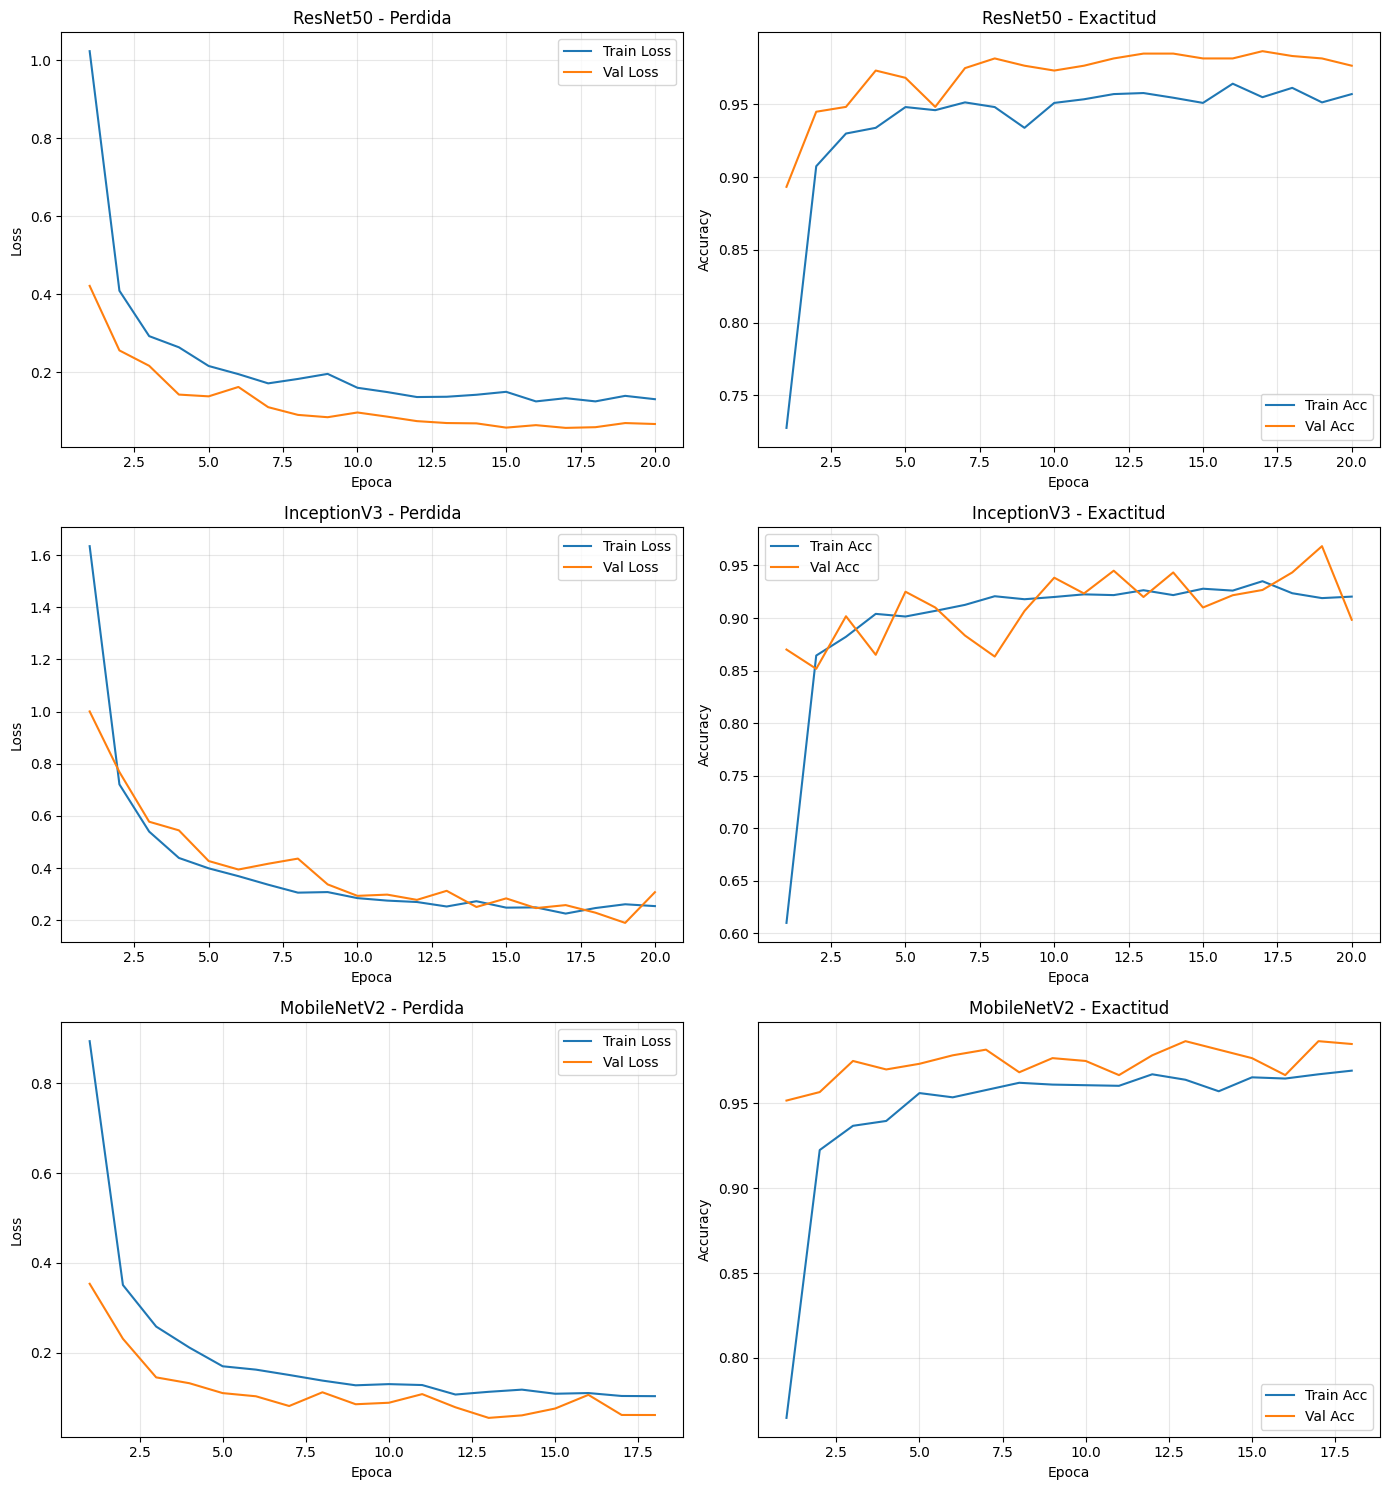

In [13]:
def plot_training_curves(histories, model_names):
    fig, axes = plt.subplots(len(model_names), 2, figsize=(14, 5 * len(model_names)))

    for i, (history, name) in enumerate(zip(histories, model_names)):
        epochs_range = range(1, len(history['train_loss']) + 1)

        # perdida
        axes[i, 0].plot(epochs_range, history['train_loss'], label='Train Loss')
        axes[i, 0].plot(epochs_range, history['val_loss'], label='Val Loss')
        axes[i, 0].set_title(f'{name} - Perdida')
        axes[i, 0].set_xlabel('Epoca')
        axes[i, 0].set_ylabel('Loss')
        axes[i, 0].legend()
        axes[i, 0].grid(True, alpha=0.3)

        # exactitud
        axes[i, 1].plot(epochs_range, history['train_acc'], label='Train Acc')
        axes[i, 1].plot(epochs_range, history['val_acc'], label='Val Acc')
        axes[i, 1].set_title(f'{name} - Exactitud')
        axes[i, 1].set_xlabel('Epoca')
        axes[i, 1].set_ylabel('Accuracy')
        axes[i, 1].legend()
        axes[i, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_curves(
    [history_resnet, history_inception, history_mobilenet],
    ['ResNet50', 'InceptionV3', 'MobileNetV2']
)

#### **Evaluación**

In [14]:
def evaluate_model(model, test_loader, model_name):
    """Evalua el modelo en el conjunto de prueba y retorna predicciones y etiquetas reales."""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')

    print(f"\n{'='*60}")
    print(f"Resultados de {model_name} en el conjunto de prueba")
    print(f"{'='*60}")
    print(f"Accuracy:       {acc:.4f} ({acc*100:.2f}%)")
    print(f"F1-Score Macro: {f1:.4f}")
    print(f"\nReporte de clasificacion detallado:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    return all_preds, all_labels, acc, f1


def get_model_size_mb(model, filepath):
    """Guarda el modelo."""
    torch.save(model.state_dict(), filepath)
    size_mb = os.path.getsize(filepath) / (1024 * 1024)
    return size_mb


def measure_inference_time(model, test_loader, num_images=100):
    """Tiempo promedio de inferencia por imagen en milisegundos."""
    model.eval()
    times = []
    count = 0

    with torch.no_grad():
        for inputs, _ in test_loader:
            for i in range(inputs.size(0)):
                if count >= num_images:
                    break
                single_input = inputs[i:i+1].to(device)

                if device.type == 'cuda':
                    torch.cuda.synchronize()
                start = time.perf_counter()
                _ = model(single_input)
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                end = time.perf_counter()

                times.append((end - start) * 1000)
                count += 1

            if count >= num_images:
                break

    avg_time = np.mean(times)
    return avg_time

#### **Evaluacion de ResNet50**

In [15]:
preds_resnet, labels_resnet, acc_resnet, f1_resnet = evaluate_model(resnet50, test_loader_224, "ResNet50")
size_resnet = get_model_size_mb(resnet50, "resnet50_mango.pth")
time_resnet = measure_inference_time(resnet50, test_loader_224, num_images=100)

print(f"Tamano del modelo: {size_resnet:.2f} MB")
print(f"Tiempo de inferencia promedio: {time_resnet:.2f} ms/imagen")


Resultados de ResNet50 en el conjunto de prueba
Accuracy:       0.9750 (97.50%)
F1-Score Macro: 0.9750

Reporte de clasificacion detallado:
                  precision    recall  f1-score   support

     Anthracnose       0.99      0.97      0.98        75
Bacterial Canker       0.99      0.97      0.98        75
  Cutting Weevil       1.00      1.00      1.00        75
        Die Back       0.99      1.00      0.99        75
      Gall Midge       0.91      0.97      0.94        75
         Healthy       0.99      1.00      0.99        75
  Powdery Mildew       0.99      0.95      0.97        75
     Sooty Mould       0.96      0.93      0.95        75

        accuracy                           0.97       600
       macro avg       0.98      0.98      0.98       600
    weighted avg       0.98      0.97      0.98       600

Tamano del modelo: 90.04 MB
Tiempo de inferencia promedio: 9.40 ms/imagen


#### **Evaluacion de InceptionV3**

In [16]:
preds_inception, labels_inception, acc_inception, f1_inception = evaluate_model(inceptionv3, test_loader_299, "InceptionV3")
size_inception = get_model_size_mb(inceptionv3, "inceptionv3_mango.pth")
time_inception = measure_inference_time(inceptionv3, test_loader_299, num_images=100)

print(f"Tamano del modelo: {size_inception:.2f} MB")
print(f"Tiempo de inferencia promedio: {time_inception:.2f} ms/imagen")


Resultados de InceptionV3 en el conjunto de prueba
Accuracy:       0.9350 (93.50%)
F1-Score Macro: 0.9350

Reporte de clasificacion detallado:
                  precision    recall  f1-score   support

     Anthracnose       0.82      0.93      0.88        75
Bacterial Canker       1.00      0.92      0.96        75
  Cutting Weevil       0.96      1.00      0.98        75
        Die Back       0.96      0.97      0.97        75
      Gall Midge       0.97      0.84      0.90        75
         Healthy       0.93      1.00      0.96        75
  Powdery Mildew       0.92      0.91      0.91        75
     Sooty Mould       0.94      0.91      0.93        75

        accuracy                           0.94       600
       macro avg       0.94      0.94      0.94       600
    weighted avg       0.94      0.94      0.94       600

Tamano del modelo: 93.28 MB
Tiempo de inferencia promedio: 18.49 ms/imagen


#### **Evaluacion de MobileNetV2**

In [17]:
preds_mobilenet, labels_mobilenet, acc_mobilenet, f1_mobilenet = evaluate_model(mobilenetv2, test_loader_224, "MobileNetV2")
size_mobilenet = get_model_size_mb(mobilenetv2, "mobilenetv2_mango.pth")
time_mobilenet = measure_inference_time(mobilenetv2, test_loader_224, num_images=100)

print(f"Tamano del modelo: {size_mobilenet:.2f} MB")
print(f"Tiempo de inferencia promedio: {time_mobilenet:.2f} ms/imagen")


Resultados de MobileNetV2 en el conjunto de prueba
Accuracy:       0.9867 (98.67%)
F1-Score Macro: 0.9867

Reporte de clasificacion detallado:
                  precision    recall  f1-score   support

     Anthracnose       0.99      0.97      0.98        75
Bacterial Canker       1.00      1.00      1.00        75
  Cutting Weevil       1.00      1.00      1.00        75
        Die Back       1.00      1.00      1.00        75
      Gall Midge       0.99      0.99      0.99        75
         Healthy       0.97      1.00      0.99        75
  Powdery Mildew       0.99      0.96      0.97        75
     Sooty Mould       0.96      0.97      0.97        75

        accuracy                           0.99       600
       macro avg       0.99      0.99      0.99       600
    weighted avg       0.99      0.99      0.99       600

Tamano del modelo: 8.76 MB
Tiempo de inferencia promedio: 11.11 ms/imagen


#### **Matrices de confusión**

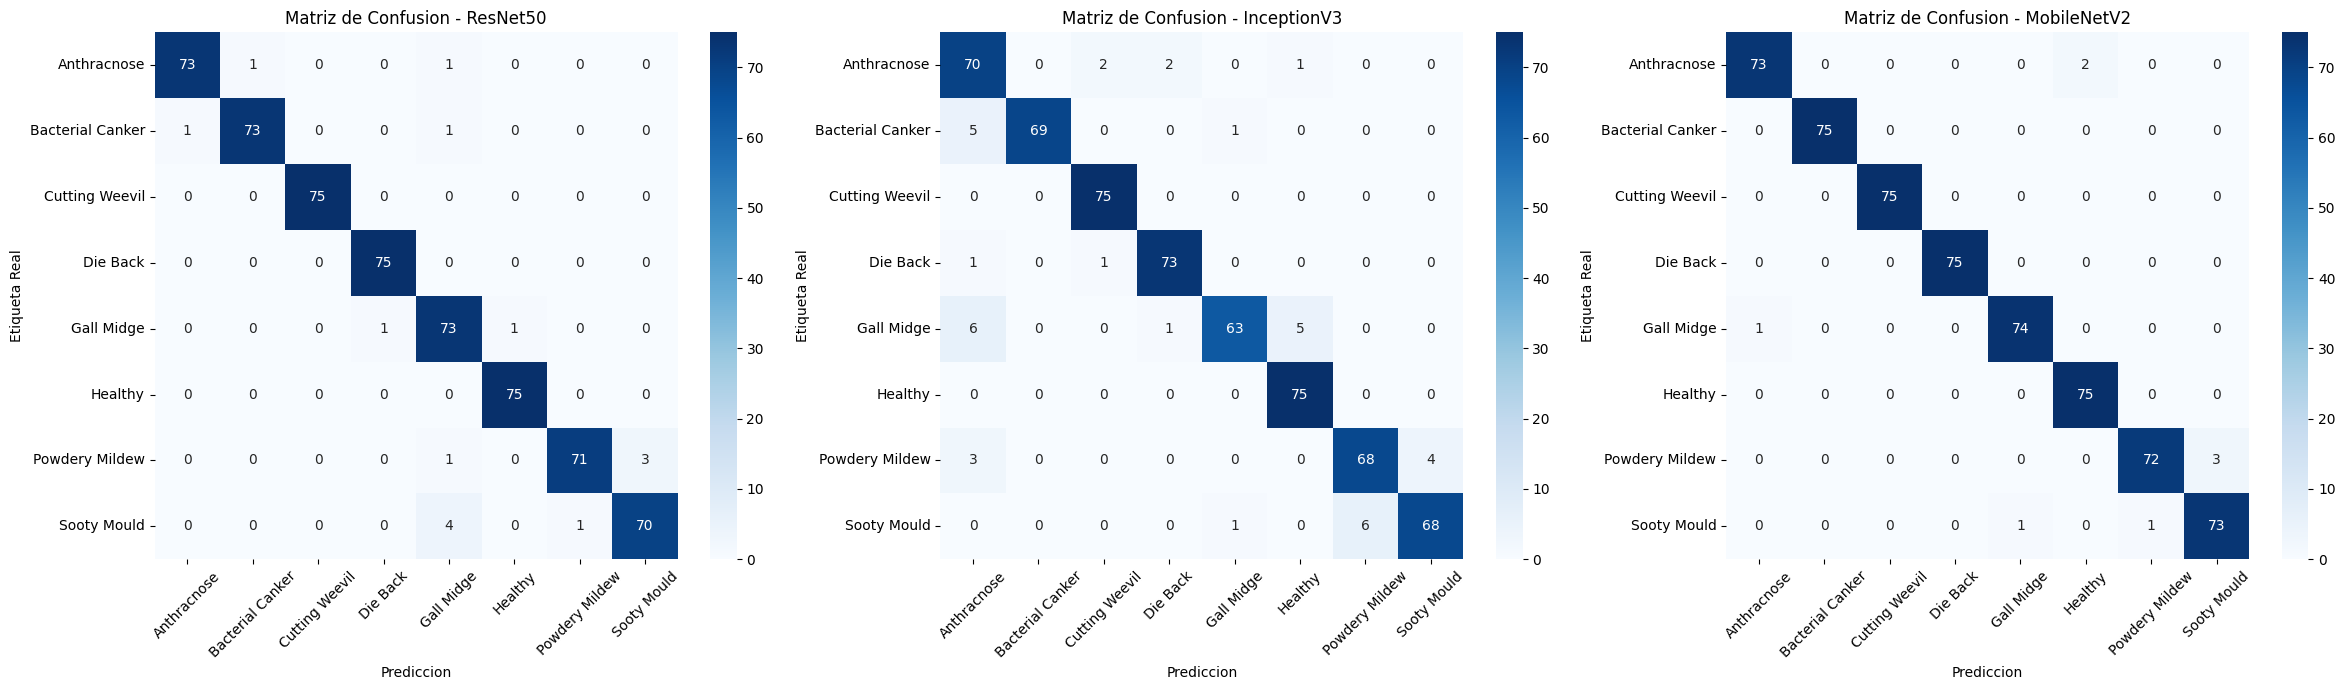

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

all_results = [
    (preds_resnet, labels_resnet, "ResNet50"),
    (preds_inception, labels_inception, "InceptionV3"),
    (preds_mobilenet, labels_mobilenet, "MobileNetV2")
]

for ax, (preds, labels, name) in zip(axes, all_results):
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'Matriz de Confusion - {name}')
    ax.set_xlabel('Prediccion')
    ax.set_ylabel('Etiqueta Real')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

#### **Comparación de resultados**

In [19]:
import pandas as pd

results_table = pd.DataFrame({
    'Modelo': ['ResNet50', 'InceptionV3', 'MobileNetV2'],
    'Accuracy (%)': [f"{acc_resnet*100:.2f}", f"{acc_inception*100:.2f}", f"{acc_mobilenet*100:.2f}"],
    'F1-Score Macro': [f"{f1_resnet:.4f}", f"{f1_inception:.4f}", f"{f1_mobilenet:.4f}"],
    'Tamano (MB)': [f"{size_resnet:.2f}", f"{size_inception:.2f}", f"{size_mobilenet:.2f}"],
    'Inferencia (ms/img)': [f"{time_resnet:.2f}", f"{time_inception:.2f}", f"{time_mobilenet:.2f}"]
})

print("\n" + "=" * 80)
print("COMPARACIÓN DE RESULTADOS")
print("=" * 80)
print(results_table.to_string(index=False))
print("=" * 80)


COMPARACIÓN DE RESULTADOS
     Modelo Accuracy (%) F1-Score Macro Tamano (MB) Inferencia (ms/img)
   ResNet50        97.50         0.9750       90.04                9.40
InceptionV3        93.50         0.9350       93.28               18.49
MobileNetV2        98.67         0.9867        8.76               11.11


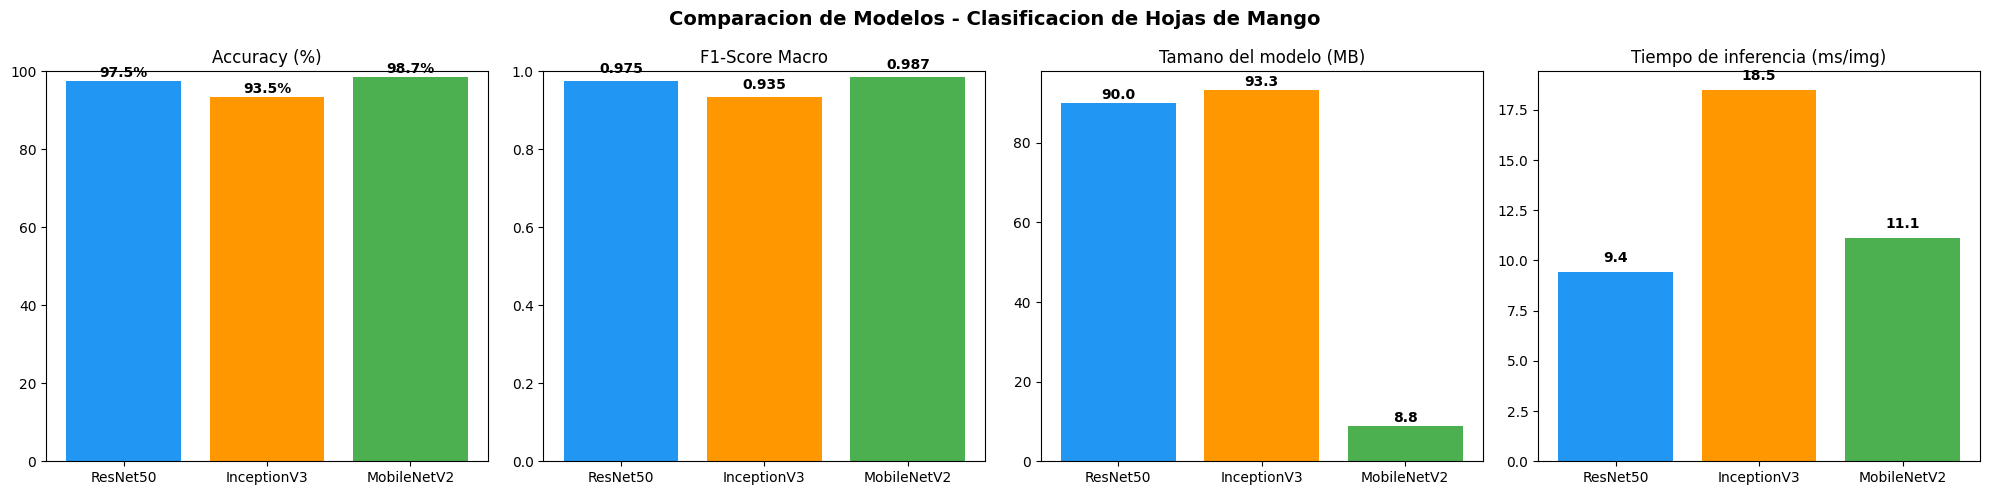

In [20]:
model_names = ['ResNet50', 'InceptionV3', 'MobileNetV2']
accuracies = [acc_resnet * 100, acc_inception * 100, acc_mobilenet * 100]
f1_scores = [f1_resnet, f1_inception, f1_mobilenet]
sizes = [size_resnet, size_inception, size_mobilenet]
inf_times = [time_resnet, time_inception, time_mobilenet]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

colors = ['#2196F3', '#FF9800', '#4CAF50']

axes[0].bar(model_names, accuracies, color=colors)
axes[0].set_title('Accuracy (%)')
axes[0].set_ylim(0, 100)
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

axes[1].bar(model_names, f1_scores, color=colors)
axes[1].set_title('F1-Score Macro')
axes[1].set_ylim(0, 1)
for i, v in enumerate(f1_scores):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

axes[2].bar(model_names, sizes, color=colors)
axes[2].set_title('Tamano del modelo (MB)')
for i, v in enumerate(sizes):
    axes[2].text(i, v + 1, f'{v:.1f}', ha='center', fontweight='bold')

axes[3].bar(model_names, inf_times, color=colors)
axes[3].set_title('Tiempo de inferencia (ms/img)')
for i, v in enumerate(inf_times):
    axes[3].text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold')

plt.suptitle('Comparacion de Modelos - Clasificacion de Hojas de Mango', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
# **Task 3**

## **Comparación de modelos**


Durante la fase de evaluación se analizaron tres arquitecturas de redes neuronales convolucionales utilizadas en visión por computadora: ResNet50, InceptionV3 y MobileNetV2. Cada modelo fue evaluado utilizando cuatro métricas relevantes para aplicaciones reales de inteligencia artificial: Accuracy, F1-Score macro, tamaño del modelo en megabytes y tiempo promedio de inferencia por imagen.

| Modelo      | Accuracy (%) | F1-Score Macro | Tamaño (MB) | Tiempo de Inferencia (ms/img) |
| ----------- | ------------ | -------------- | ----------- | ----------------------------- |
| ResNet50    | 97.50        | 0.9750         | 90.04       | 9.40 |
| InceptionV3 | 93.50        | 0.9350         | 93.28       | 18.49 |
| MobileNetV2 | 98.67    | 0.9867     | 8.76    | 11.11 |

Los resultados muestran que los tres modelos alcanzan altos niveles de desempeño en la clasificación de ocho enfermedades distintas de hojas de mango. Sin embargo, existen diferencias significativas en eficiencia computacional y tamaño del modelo.


### **ResNet50**

ResNet50 es una arquitectura profunda basada en conexiones residuales que permiten entrenar redes de muchas capas evitando el problema del vanishing gradient. Estas conexiones permiten que el modelo aprenda representaciones complejas y logre altos niveles de precisión.  
  
En este proyecto, ResNet50 alcanzó:  
Accuracy: 97.50%  
F1-score: 0.9750  

Esto demuestra una gran capacidad para identificar correctamente las enfermedades presentes en las hojas de mango. Sin embargo, el modelo presenta un tamaño considerable de 90.04 MB, lo que implica un mayor consumo de memoria en dispositivos móviles.

### **InceptionV3**

InceptionV3 utiliza una arquitectura basada en módulos Inception, donde múltiples filtros convolucionales se ejecutan en paralelo. Esta estructura permite capturar características visuales a diferentes escalas dentro de la misma imagen. Este enfoque es particularmente útil en problemas donde los patrones visuales pueden variar en tamaño, como ocurre con las enfermedades en hojas de plantas. El modelo obtuvo resultados ligeramente inferiores:  
  
Accuracy: 93.50%  
F1-score: 0.9350  
Tamaño: 93.28 MB  
Inferencia: 18.49 ms por imagen  
  
Aunque InceptionV3 deberia de haber sido mejor, su mayor complejidad computacional resulta en un modelo más pesado y con mayor tiempo de inferencia.

### **MobileNetV2**

MobileNetV2 está diseñado específicamente para aplicaciones de Edge AI y dispositivos móviles. Su eficiencia proviene del uso de Depthwise Separable Convolutions, que dividen la convolución tradicional en dos pasos,primero es Depthwise convolution, que aplica filtros espaciales independientes a cada canal. Despues es Pointwise convolution (1x1), que combina la información entre canales. Este diseño reduce drásticamente el número de parámetros y operaciones necesarias. Los resultados fueron:  
  
Accuracy: 98.67%  
F1-score: 0.9867  
Tamaño: 8.76 MB  
Inferencia: 11.11 ms por imagen  
  
MobileNetV2 no sacrificó precisión frente a las arquitecturas más grandes. De hecho, logró el mejor desempeño global, mientras mantiene un tamaño mucho menor.

Además, el tamaño en MB de los modelos está directamente relacionado con su arquitectura. Por ejemplo, ResNet mantiene muchas capas profundas, lo que incrementa el número de parámetros almacenados y por tanto el tamaño del modelo. Inception reduce parcialmente este costo mediante convoluciones 1x1 que disminuyen la dimensionalidad antes de aplicar filtros más grandes. En contraste, MobileNet utiliza Depthwise Separable Convolutions, que separan el filtrado espacial de la combinación de canales, reduciendo significativamente el número de operaciones y parámetros. Por esta razón MobileNet suele ocupar menos memoria y producir modelos más ligeros, lo cual se refleja directamente en el tamaño final en MB observado en los resultados.

## **Producción**
Para producción el sistema será utilizado por agricultores guatemaltecos en teléfonos Android con aproximadamente 2GB de RAM y sin conexión a internet. Esto implica que el modelo debe ejecutarse completamente en el dispositivo, sin depender de servidores externos o computación en la nube. Bajo estas condiciones, el modelo recomendado es MobileNetV2. Principalmente por el poco espacio que tiene que ocupar en los celulares. Las razones principales son:

1. Tamaño reducido: MobileNetV2 ocupa solo 8.76 MB, mientras que ResNet50 e InceptionV3 superan los 90 MB. Esto facilita su almacenamiento y ejecución en dispositivos móviles de gama baja.

2. Alto desempeño: El modelo alcanzó 98.67% de accuracy (el mejor), superando incluso a los otros modelos evaluados. Esto demuestra que su eficiencia computacional no compromete la calidad de las predicciones.

3. Diseñado para Edge AI: MobileNetV2 fue desarrollado específicamente para dispositivos móviles y sistemas embebidos, utilizando convoluciones separables que reducen significativamente el costo computacional.

4. Tiempo de inferencia adecuado: Con 11.11 ms por imagen, el modelo puede ofrecer diagnósticos prácticamente en tiempo real para los agricultores.

### **Conclusión**
Tras evaluar tres arquitecturas de redes neuronales profundas, se concluye que MobileNetV2 ofrece el mejor equilibrio entre precisión, eficiencia computacional y tamaño del modelo. Mientras que ResNet50 e InceptionV3 alcanzan resultados competitivos, su mayor tamaño y complejidad los hacen menos adecuados para aplicaciones móviles offline. Por lo tanto, MobileNetV2 es el modelo recomendado para su despliegue en producción, permitiendo a los agricultores guatemaltecos diagnosticar enfermedades en hojas de mango directamente desde sus teléfonos, incluso en entornos rurales sin conectividad a internet.

---

## Prompt Utilizado

**Uso de ChatGPT**

**Task 1**


**Task 2**


**Task 3**


**Por que funciono este prompt**

---